# Phase 1 — Research Visualization Notebook

Publication-oriented figures for the traffic congestion prediction system.  
Uses **matplotlib.pyplot** and **seaborn** and reads real project artifacts; it does not fabricate results.

Core paper figures:
1. Traffic-speed distribution
2. Temporal traffic-speed trend
3. Multi-sensor traffic heatmap
4. Feature correlation heatmap
5. Actual vs predicted
6. Prediction residuals
7. Model comparison
8. Congestion-class distribution
9. SHAP feature importance

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
})

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Change these four paths to the actual artifacts generated by your project.
PREPARED_DATA = PROJECT_ROOT / "data" / "processed" / "prepared_dataset.csv"
PREDICTIONS_FILE = RESULTS_DIR / "predictions.csv"
METRICS_FILE = RESULTS_DIR / "metrics.csv"
SHAP_FILE = RESULTS_DIR / "shap_values.csv"

print("Project root:", PROJECT_ROOT)
print("Figures:", FIGURES_DIR)

Project root: D:\python\projects\traffic-congestion-prediction
Figures: D:\python\projects\traffic-congestion-prediction\results\figures


## 1. Load prepared traffic data

In [7]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "data").is_dir():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError(
            "Could not locate project root containing the 'data' directory."
        )
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_DATA = PROCESSED_DIR / "train.csv"
VALIDATION_DATA = PROCESSED_DIR / "validation.csv"
TEST_DATA = PROCESSED_DIR / "test.csv"

print("Project root:", PROJECT_ROOT)
print("Training data:", TRAIN_DATA)
print("Exists:", TRAIN_DATA.exists())

Project root: D:\python\projects\traffic-congestion-prediction
Training data: D:\python\projects\traffic-congestion-prediction\data\processed\train.csv
Exists: True


In [8]:
train_df = pd.read_csv(TRAIN_DATA)

train_df["timestamp"] = pd.to_datetime(
    train_df["timestamp"],
    errors="coerce",
)

sensor_columns = [
    column
    for column in train_df.columns
    if column != "timestamp"
]

print("Training shape:", train_df.shape)
print("Number of sensors:", len(sensor_columns))
print("First sensors:", sensor_columns[:10])
print("Timestamp range:")
print(train_df["timestamp"].min())
print(train_df["timestamp"].max())

Training shape: (23990, 208)
Number of sensors: 207
First sensors: ['773869', '767541', '767542', '717447', '717446', '717445', '773062', '767620', '737529', '717816']
Timestamp range:
2012-03-01 00:00:00
2012-05-23 07:05:00


In [3]:
train_path = PROJECT_ROOT / "data" / "processed" / "train.csv"

print("Training dataset:")
print(train_path)
print("Exists:", train_path.exists())

Training dataset:
D:\python\projects\traffic-congestion-prediction\data\processed\train.csv
Exists: True


In [4]:
from pathlib import Path
import pandas as pd

df = pd.read_csv(train_path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Shape: (23990, 208)

Columns:
['timestamp', '773869', '767541', '767542', '717447', '717446', '717445', '773062', '767620', '737529', '717816', '765604', '767471', '716339', '773906', '765273', '716331', '771667', '716337', '769953', '769402', '769403', '769819', '769405', '716941', '717578', '716960', '717804', '767572', '767573', '773012', '773013', '764424', '769388', '716328', '717819', '769941', '760987', '718204', '718045', '769418', '768066', '772140', '773927', '760024', '774012', '774011', '767609', '769359', '760650', '716956', '769831', '761604', '717495', '716554', '773953', '767470', '716955', '764949', '773954', '767366', '769444', '773939', '774067', '769443', '767750', '767751', '767610', '773880', '764766', '717497', '717490', '717491', '717492', '717493', '765176', '717498', '717499', '765171', '718064', '718066', '765164', '769431', '769430', '717610', '767053', '767621', '772596', '772597', '767350', '767351', '716571', '773023', '767585', '773024', '717483', '71837

,timestamp,773869,767541,767542,717447,717446,717445,773062,767620,737529,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
0,2012-03-01 00:00:00,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000,65.125,67.125,59.625000,...,45.625000,65.500,64.500000,66.428571,66.875,59.375000,69.000000,59.250000,69.000000,61.875
1,2012-03-01 00:05:00,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,65.000,65.000,57.444444,...,50.666667,69.875,66.666667,58.555556,62.000,61.111111,64.444444,55.888889,68.444444,62.875
2,2012-03-01 00:10:00,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,64.500,64.250,63.875000,...,44.125000,69.000,56.500000,59.250000,68.125,62.500000,65.625000,61.375000,69.857143,62.000
3,2012-03-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000
4,2012-03-01 00:20:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000


In [ ]:
def first_existing(columns, candidates):
    return next((c for c in candidates if c in columns), None)

if not PREPARED_DATA.exists():
    raise FileNotFoundError(
        f"Update PREPARED_DATA; file not found: {PREPARED_DATA}"
    )

df = pd.read_csv(PREPARED_DATA)

timestamp_col = first_existing(
    df.columns, ["timestamp", "datetime", "date_time", "time"]
)
speed_col = first_existing(
    df.columns, ["speed", "traffic_speed", "average_speed", "avg_speed"]
)
flow_col = first_existing(
    df.columns, ["traffic_flow", "flow", "vehicle_flow", "volume"]
)
sensor_col = first_existing(
    df.columns, ["sensor_id", "sensor", "road_segment_id", "station_id"]
)

if timestamp_col:
    df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors="coerce")
    df = df.dropna(subset=[timestamp_col]).sort_values(timestamp_col)

print("Shape:", df.shape)
print("Timestamp:", timestamp_col)
print("Speed:", speed_col)
print("Flow:", flow_col)
print("Sensor:", sensor_col)

FileNotFoundError: Update PREPARED_DATA; file not found: D:\python\projects\traffic-congestion-prediction\data\processed\prepared_dataset.csv

## 2. Figure 1 — Traffic-speed distribution

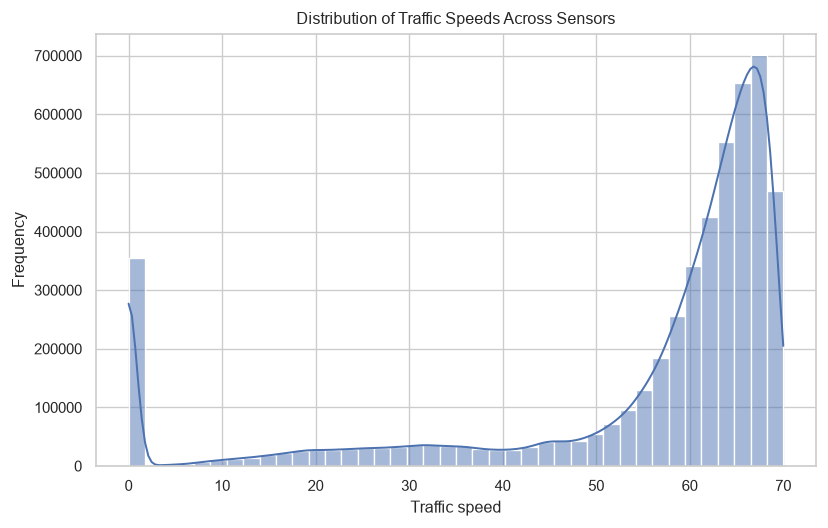

In [9]:
all_speeds = train_df[sensor_columns].to_numpy().ravel()

all_speeds = all_speeds[
    np.isfinite(all_speeds)
]

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.histplot(
    all_speeds,
    bins=40,
    kde=True,
    ax=ax,
)

ax.set_title("Distribution of Traffic Speeds Across Sensors")
ax.set_xlabel("Traffic speed")
ax.set_ylabel("Frequency")

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "fig01_speed_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 3. Figure 2 — Temporal traffic-speed trend

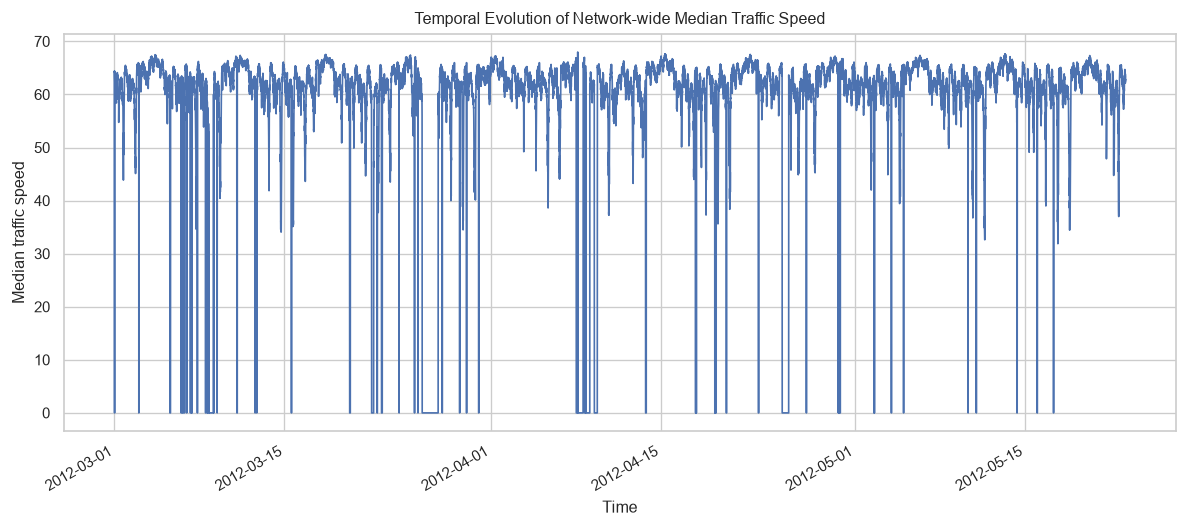

In [10]:
train_df["network_median_speed"] = train_df[
    sensor_columns
].median(axis=1)

fig, ax = plt.subplots(figsize=(10, 4.5))

sns.lineplot(
    data=train_df,
    x="timestamp",
    y="network_median_speed",
    linewidth=1.0,
    ax=ax,
)

ax.set_title("Temporal Evolution of Network-wide Median Traffic Speed")
ax.set_xlabel("Time")
ax.set_ylabel("Median traffic speed")

fig.autofmt_xdate()

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "fig02_network_temporal_trend.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 4. Figure 3 — Multi-sensor traffic-speed heatmap

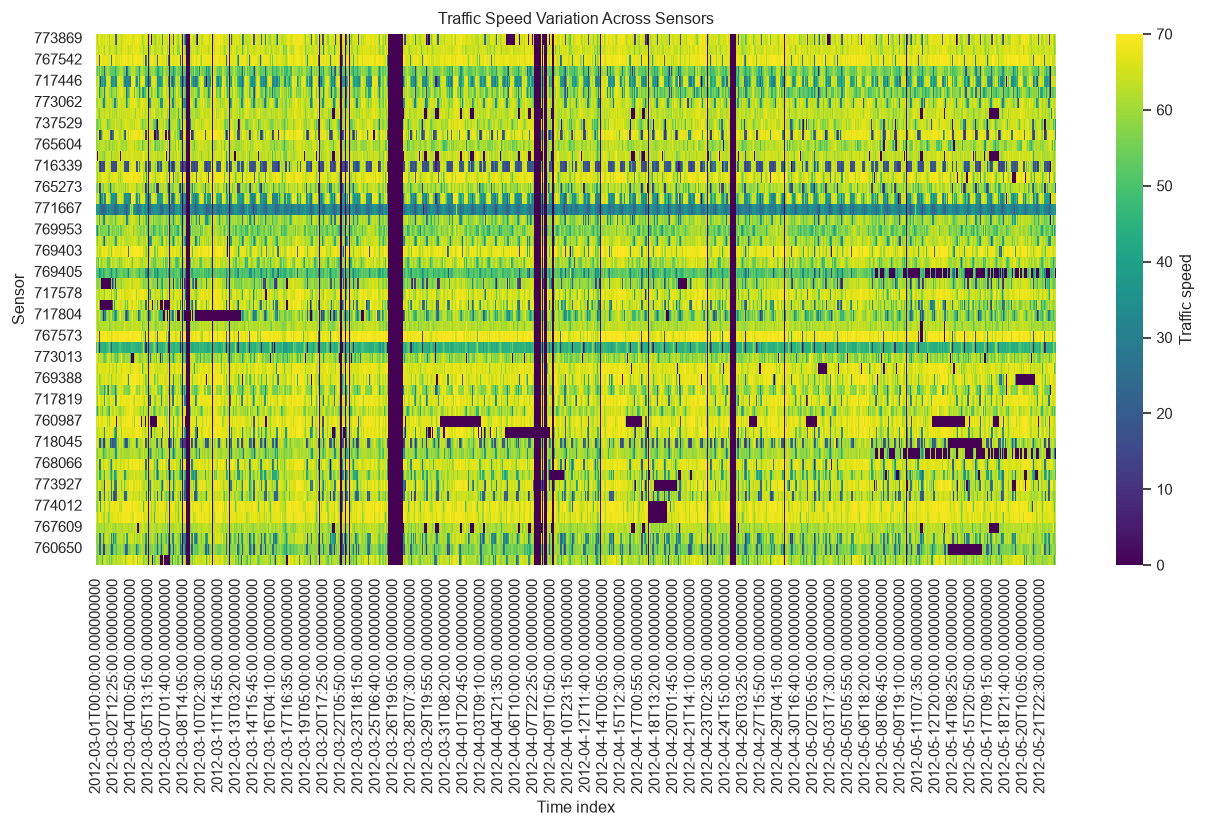

In [11]:
heatmap_data = train_df.set_index("timestamp")[sensor_columns]

# Show a manageable portion for publication.
# The underlying experiment still uses all 207 sensors.
heatmap_display = heatmap_data.iloc[:, :50]

fig, ax = plt.subplots(figsize=(11, 7))

sns.heatmap(
    heatmap_display.T,
    cmap="viridis",
    cbar_kws={"label": "Traffic speed"},
    ax=ax,
)

ax.set_title("Traffic Speed Variation Across Sensors")
ax.set_xlabel("Time index")
ax.set_ylabel("Sensor")

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "fig03_multisensor_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 5. Figure 4 — Sesnor correlation heatmap

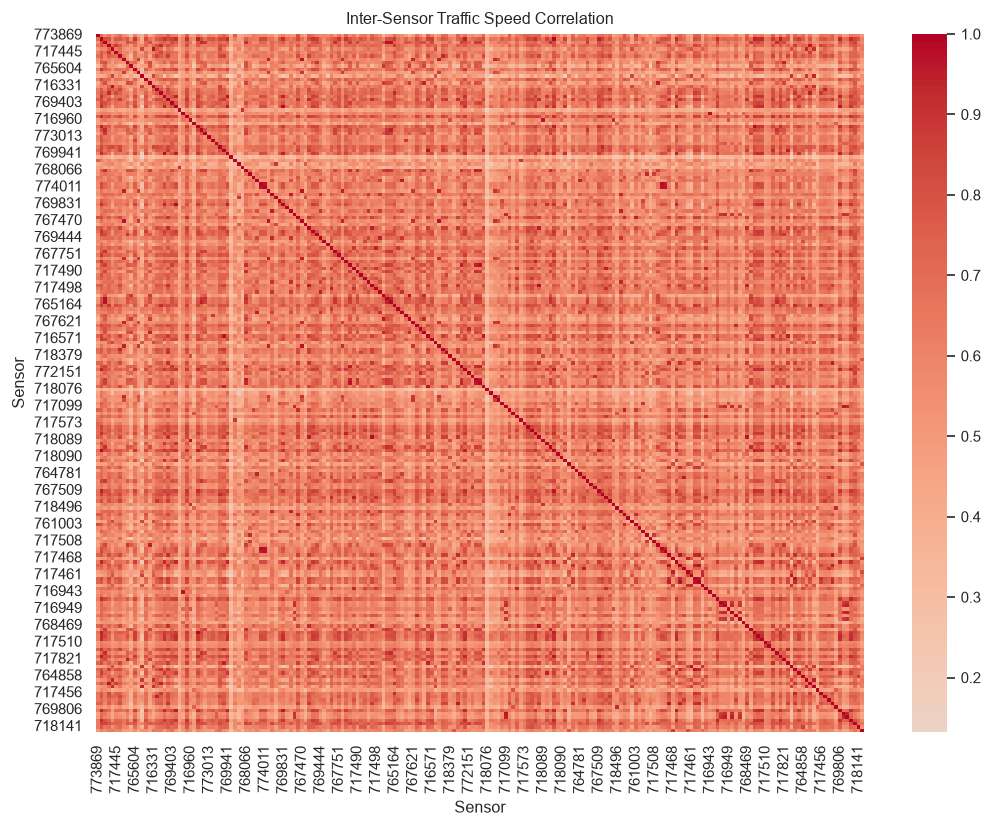

In [12]:
sensor_correlation = train_df[sensor_columns].corr()

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    sensor_correlation,
    cmap="coolwarm",
    center=0,
    ax=ax,
)

ax.set_title("Inter-Sensor Traffic Speed Correlation")
ax.set_xlabel("Sensor")
ax.set_ylabel("Sensor")

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "fig04_sensor_correlation.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

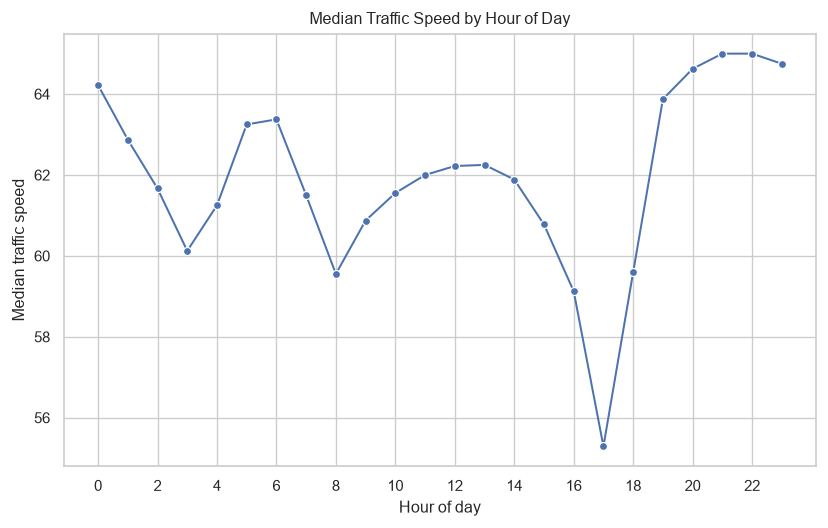

In [13]:
train_df["hour"] = train_df["timestamp"].dt.hour

hourly_speed = (
    train_df
    .groupby("hour")["network_median_speed"]
    .median()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.lineplot(
    data=hourly_speed,
    x="hour",
    y="network_median_speed",
    marker="o",
    ax=ax,
)

ax.set_title("Median Traffic Speed by Hour of Day")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Median traffic speed")
ax.set_xticks(range(0, 24, 2))

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "fig05_hourly_pattern.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

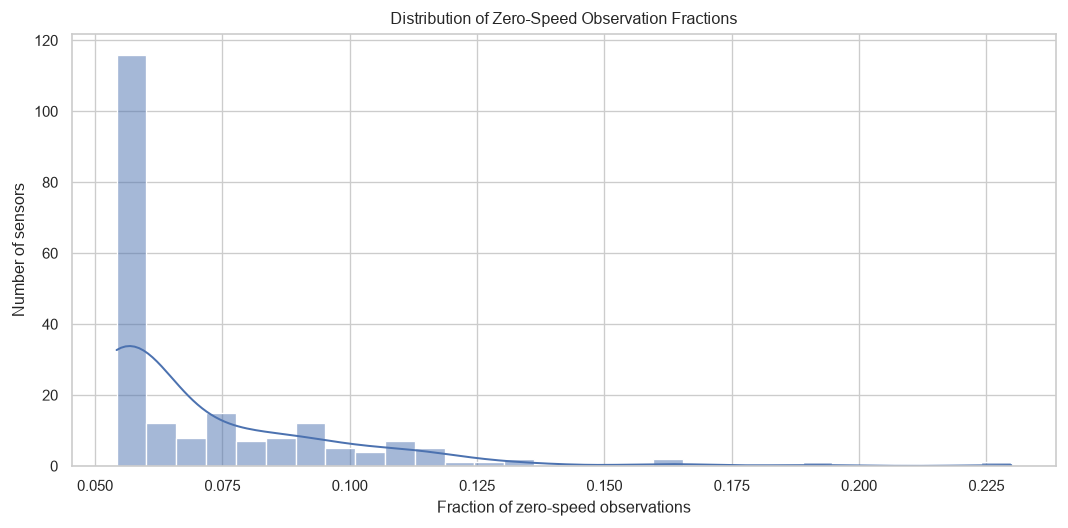

In [14]:
zero_fraction = (
    (train_df[sensor_columns] <= 0.0)
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 4.5))

sns.histplot(
    zero_fraction,
    bins=30,
    kde=True,
    ax=ax,
)

ax.set_title("Distribution of Zero-Speed Observation Fractions")
ax.set_xlabel("Fraction of zero-speed observations")
ax.set_ylabel("Number of sensors")

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "fig06_zero_speed_fraction.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [15]:
results = pd.DataFrame({
    "split": ["Validation", "Test"],
    "MAE": [4.6567, 4.6272],
    "RMSE": [9.5430, 9.2205],
    "sMAPE": [24.93, 32.77],
})

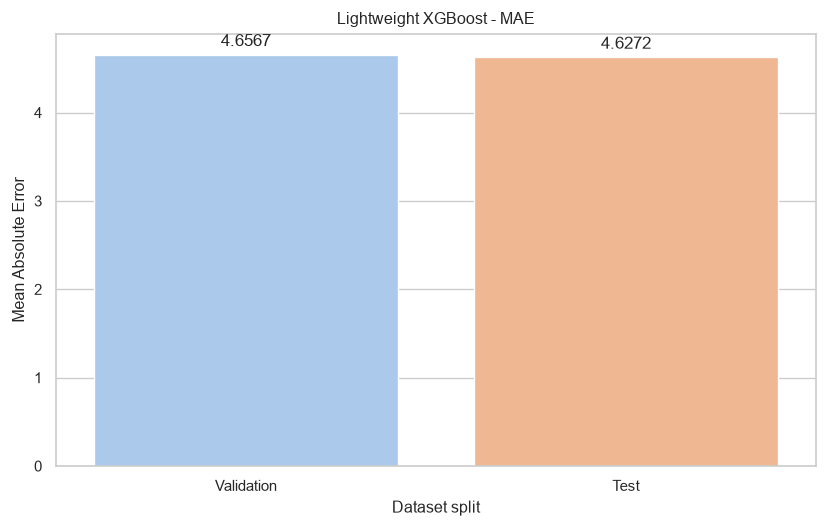

In [18]:
fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(
    data=results,
    x="split",
    y="MAE",
    ax=ax,
    hue="split",
    palette=sns.color_palette("pastel")
)

ax.set_title("Lightweight XGBoost - MAE")
ax.set_xlabel("Dataset split")
ax.set_ylabel("Mean Absolute Error")

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "xgboost_mae_validation_test.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

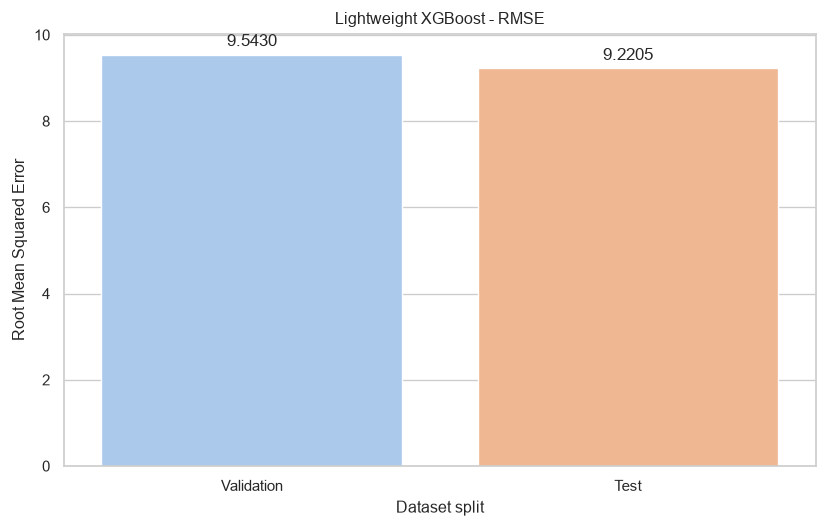

In [20]:
fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(
    data=results,
    x="split",
    y="RMSE",
    ax=ax,
    hue="split",
    palette=sns.color_palette("pastel")
)

ax.set_title("Lightweight XGBoost - RMSE")
ax.set_xlabel("Dataset split")
ax.set_ylabel("Root Mean Squared Error")

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "xgboost_rmse_validation_test.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

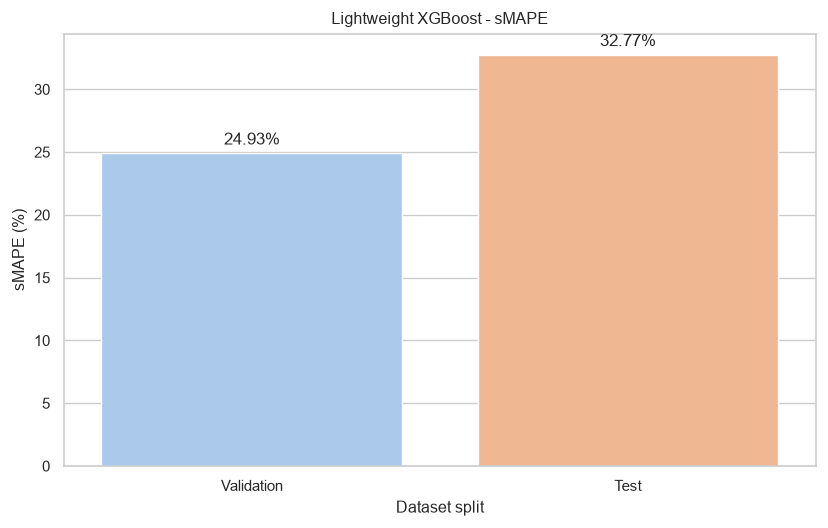

In [22]:
fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(
    data=results,
    x="split",
    y="sMAPE",
    ax=ax,
    hue="split",
    palette=sns.color_palette("pastel")
)

ax.set_title("Lightweight XGBoost - sMAPE")
ax.set_xlabel("Dataset split")
ax.set_ylabel("sMAPE (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "xgboost_smape_validation_test.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

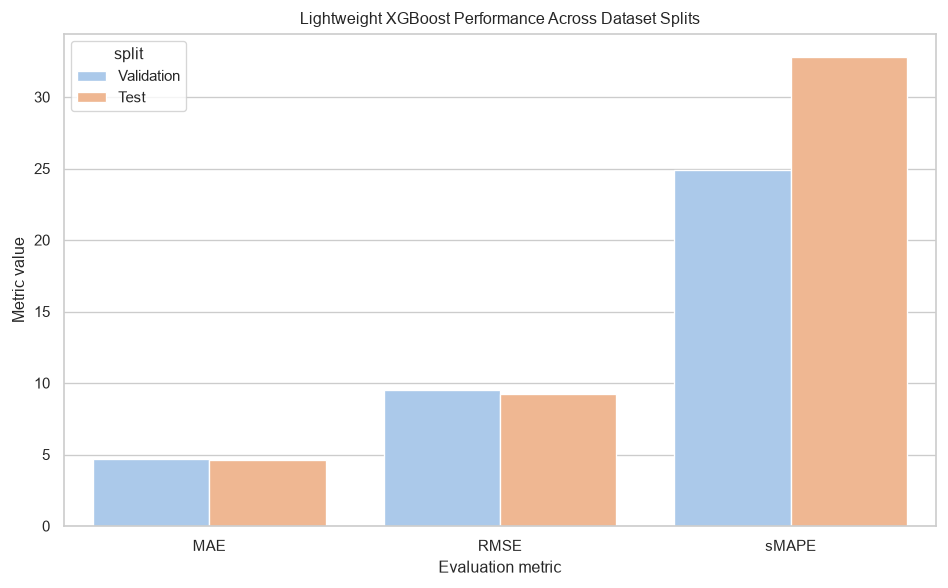

In [24]:
metrics_long = results.melt(
    id_vars="split",
    value_vars=["MAE", "RMSE", "sMAPE"],
    var_name="Metric",
    value_name="Value",
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=metrics_long,
    x="Metric",
    y="Value",
    hue="split",
    palette=sns.color_palette("pastel"),
    ax=ax,
)

ax.set_title("Lightweight XGBoost Performance Across Dataset Splits")
ax.set_xlabel("Evaluation metric")
ax.set_ylabel("Metric value")

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "xgboost_performance_validation_test.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [25]:
generalization = results.set_index("split")

difference = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "sMAPE"],
    "Validation": [
        generalization.loc["Validation", "MAE"],
        generalization.loc["Validation", "RMSE"],
        generalization.loc["Validation", "sMAPE"],
    ],
    "Test": [
        generalization.loc["Test", "MAE"],
        generalization.loc["Test", "RMSE"],
        generalization.loc["Test", "sMAPE"],
    ],
})

difference["Absolute Difference"] = (
    difference["Test"] - difference["Validation"]
)

difference

,Metric,Validation,Test,Absolute Difference
0,MAE,4.6567,4.6272,-0.0295
1,RMSE,9.5430,9.2205,-0.3225
2,sMAPE,24.9300,32.7700,7.8400


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(
    data=results,
    x="split",
    y="sMAPE",
    ax=ax,
)

ax.set_title("Lightweight XGBoost — sMAPE")
ax.set_xlabel("Dataset split")
ax.set_ylabel("sMAPE (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "xgboost_smape_validation_test.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 6. Figure 5 — Actual vs predicted

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper")

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
})

# Locate project root automatically
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "data").is_dir():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not locate project root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Figures directory:", FIGURES_DIR)

Project root: D:\python\projects\traffic-congestion-prediction
Figures directory: D:\python\projects\traffic-congestion-prediction\results\figures


In [2]:
results = pd.DataFrame([
    {
        "Model": "Persistence",
        "Split": "Validation",
        "MAE": 4.0593,
        "RMSE": 9.9222,
        "sMAPE": 11.18,
    },
    {
        "Model": "XGBoost",
        "Split": "Validation",
        "MAE": 4.6567,
        "RMSE": 9.5430,
        "sMAPE": 24.93,
    },
    {
        "Model": "GRU",
        "Split": "Validation",
        "MAE": 4.0459,
        "RMSE": 9.8186,
        "sMAPE": 25.15,
    },
    {
        "Model": "Persistence",
        "Split": "Test",
        "MAE": 3.8795,
        "RMSE": 9.5040,
        "sMAPE": 11.02,
    },
    {
        "Model": "XGBoost",
        "Split": "Test",
        "MAE": 4.6272,
        "RMSE": 9.2205,
        "sMAPE": 32.77,
    },
    {
        "Model": "GRU",
        "Split": "Test",
        "MAE": 3.9040,
        "RMSE": 9.4304,
        "sMAPE": 33.01,
    },
])

results

,Model,Split,MAE,RMSE,sMAPE
0,Persistence,Validation,4.0593,9.9222,11.18
1,XGBoost,Validation,4.6567,9.5430,24.93
2,GRU,Validation,4.0459,9.8186,25.15
3,Persistence,Test,3.8795,9.5040,11.02
4,XGBoost,Test,4.6272,9.2205,32.77
5,GRU,Test,3.9040,9.4304,33.01


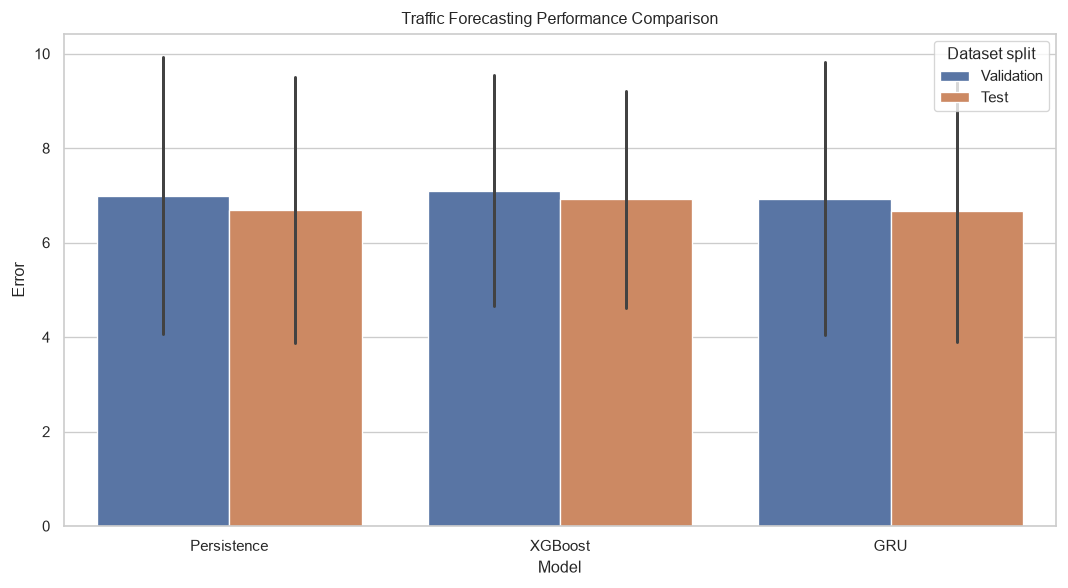

In [3]:
plot_df = results.melt(
    id_vars=["Model", "Split"],
    value_vars=["MAE", "RMSE"],
    var_name="Metric",
    value_name="Error",
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=plot_df,
    x="Model",
    y="Error",
    hue="Split",
    ax=ax,
)

ax.set_title(
    "Traffic Forecasting Performance Comparison"
)

ax.set_xlabel("Model")
ax.set_ylabel("Error")

ax.legend(
    title="Dataset split",
    loc="upper right",
)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "forecasting_model_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

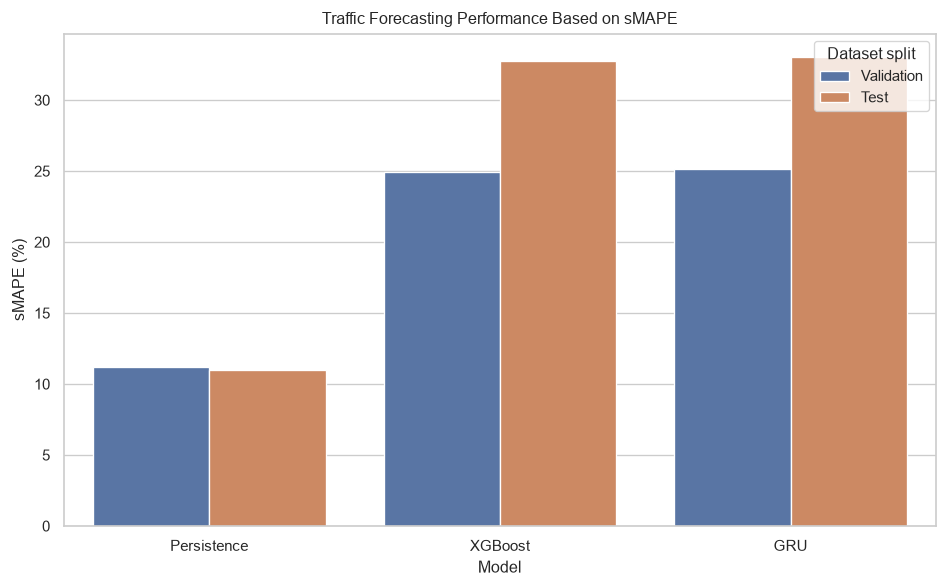

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="sMAPE",
    hue="Split",
    ax=ax,
)

ax.set_title(
    "Traffic Forecasting Performance Based on sMAPE"
)

ax.set_xlabel("Model")
ax.set_ylabel("sMAPE (%)")

ax.legend(
    title="Dataset split",
    loc="upper right",
)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "forecasting_smape_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [5]:
y_test_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "sequences"
    / "y_test.npy"
)

gru_prediction_path = (
    RESULTS_DIR
    / "predictions"
    / "gru_residual_test.npy"
)

y_test = np.load(y_test_path)
gru_predictions = np.load(gru_prediction_path)

print("Actual shape:    ", y_test.shape)
print("Prediction shape:", gru_predictions.shape)

assert y_test.shape == gru_predictions.shape

print("Shape verification: PASS")

Actual shape:     (5128, 207)
Prediction shape: (5128, 207)
Shape verification: PASS


In [6]:
actual_network_speed = np.median(
    y_test,
    axis=1,
)

predicted_network_speed = np.median(
    gru_predictions,
    axis=1,
)

print("Network actual shape:",
      actual_network_speed.shape)

print("Network predicted shape:",
      predicted_network_speed.shape)

Network actual shape: (5128,)
Network predicted shape: (5128,)


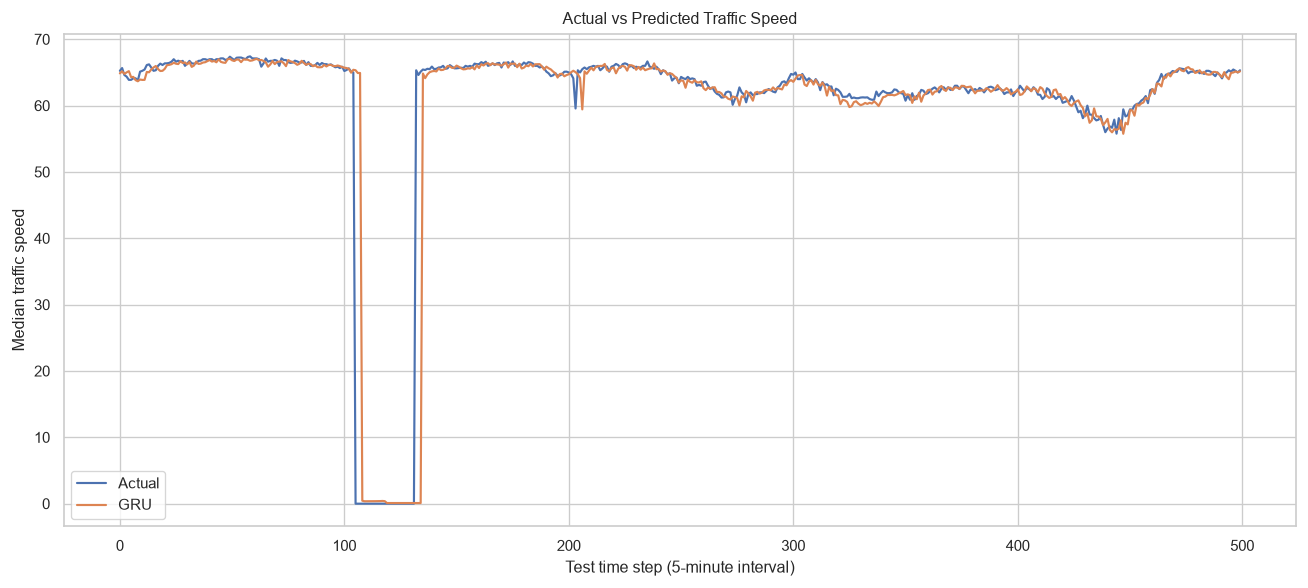

In [7]:
# Plot the first 500 test observations
# 500 observations × 5 minutes = approximately 41.7 hours

N = min(500, len(actual_network_speed))

time_steps = np.arange(N)

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    time_steps,
    actual_network_speed[:N],
    label="Actual",
    linewidth=1.3,
)

ax.plot(
    time_steps,
    predicted_network_speed[:N],
    label="GRU",
    linewidth=1.3,
)

ax.set_title(
    "Actual vs Predicted Traffic Speed"
)

ax.set_xlabel(
    "Test time step (5-minute interval)"
)

ax.set_ylabel(
    "Median traffic speed"
)

ax.legend()

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "gru_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

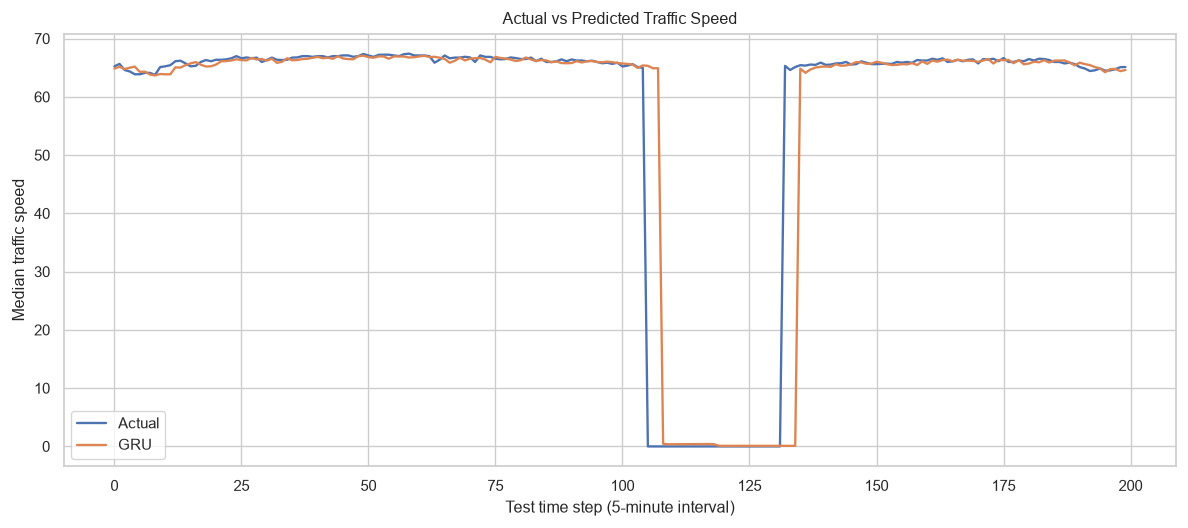

In [8]:
N = min(200, len(actual_network_speed))

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(
    actual_network_speed[:N],
    label="Actual",
    linewidth=1.4,
)

ax.plot(
    predicted_network_speed[:N],
    label="GRU",
    linewidth=1.4,
)

ax.set_title(
    "Actual vs Predicted Traffic Speed"
)

ax.set_xlabel(
    "Test time step (5-minute interval)"
)

ax.set_ylabel(
    "Median traffic speed"
)

ax.legend()

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "gru_actual_vs_predicted_representative.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [ ]:
if not PREDICTIONS_FILE.exists():
    print("Skipped:", PREDICTIONS_FILE)
else:
    pred = pd.read_csv(PREDICTIONS_FILE)

    required = {"actual", "predicted"}
    missing = required - set(pred.columns)
    if missing:
        raise ValueError(
            f"Prediction file is missing columns: {sorted(missing)}"
        )

    if "split" in pred.columns:
        test_mask = pred["split"].astype(str).str.lower().eq("test")
        if test_mask.any():
            pred = pred.loc[test_mask]

    plot_pred = pred.head(2000)

    fig, ax = plt.subplots(figsize=(6, 6))
    sns.scatterplot(
        data=plot_pred,
        x="actual",
        y="predicted",
        s=25,
        alpha=0.5,
        ax=ax,
    )

    lo = min(plot_pred["actual"].min(), plot_pred["predicted"].min())
    hi = max(plot_pred["actual"].max(), plot_pred["predicted"].max())
    ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.2)

    ax.set_title("Actual vs Predicted Traffic Speed")
    ax.set_xlabel("Actual speed")
    ax.set_ylabel("Predicted speed")
    fig.tight_layout()
    fig.savefig(
        FIGURES_DIR / "fig05_actual_vs_predicted.png",
        bbox_inches="tight",
    )
    plt.show()

## 7. Figure 6 — Prediction residual distribution

In [ ]:
if not PREDICTIONS_FILE.exists():
    print("Skipped:", PREDICTIONS_FILE)
else:
    pred = pd.read_csv(PREDICTIONS_FILE)
    pred["residual"] = pred["actual"] - pred["predicted"]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    sns.histplot(pred["residual"].dropna(), bins=35, kde=True, ax=ax)
    ax.axvline(0, linestyle="--", linewidth=1.2)

    ax.set_title("Prediction Residual Distribution")
    ax.set_xlabel("Residual (actual - predicted)")
    ax.set_ylabel("Frequency")
    fig.tight_layout()
    fig.savefig(
        FIGURES_DIR / "fig06_residual_distribution.png",
        bbox_inches="tight",
    )
    plt.show()

## 8. Figure 7 — Model comparison

In [ ]:
if not METRICS_FILE.exists():
    print("Skipped:", METRICS_FILE)
else:
    metrics = pd.read_csv(METRICS_FILE)

    required = {"model_name", "mae", "rmse"}
    missing = required - set(metrics.columns)
    if missing:
        raise ValueError(
            f"Metrics file is missing columns: {sorted(missing)}"
        )

    if "split" in metrics.columns:
        test_mask = metrics["split"].astype(str).str.lower().eq("test")
        if test_mask.any():
            metrics = metrics.loc[test_mask]

    metric_cols = [
        c for c in ["mae", "rmse", "smape", "mape"]
        if c in metrics.columns
    ]

    long_metrics = metrics.melt(
        id_vars=["model_name"],
        value_vars=metric_cols,
        var_name="metric",
        value_name="value",
    )

    fig, ax = plt.subplots(figsize=(8, 4.8))
    sns.barplot(
        data=long_metrics,
        x="model_name",
        y="value",
        hue="metric",
        ax=ax,
    )
    ax.set_title("Test-set Prediction Error Comparison")
    ax.set_xlabel("Model")
    ax.set_ylabel("Error")
    ax.tick_params(axis="x", rotation=25)
    fig.tight_layout()
    fig.savefig(
        FIGURES_DIR / "fig07_model_comparison.png",
        bbox_inches="tight",
    )
    plt.show()

## 9. Figure 8 — Congestion-class distribution

In [ ]:
class_col = first_existing(
    df.columns,
    ["congestion_class", "congestion_level", "class", "target_class"],
)

if class_col is None:
    print("Skipped: no congestion-class column found.")
else:
    counts = (
        df[class_col]
        .value_counts(dropna=False)
        .rename_axis("class")
        .reset_index(name="count")
    )

    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    sns.barplot(data=counts, x="class", y="count", ax=ax)
    ax.set_title("Congestion-Class Distribution")
    ax.set_xlabel("Congestion class")
    ax.set_ylabel("Observations")
    fig.tight_layout()
    fig.savefig(
        FIGURES_DIR / "fig08_congestion_class_distribution.png",
        bbox_inches="tight",
    )
    plt.show()

## 10. Figure 9 — SHAP feature importance

In [ ]:
if not SHAP_FILE.exists():
    print("Skipped:", SHAP_FILE)
else:
    shap_df = pd.read_csv(SHAP_FILE)

    required = {"feature", "shap_value"}
    missing = required - set(shap_df.columns)
    if missing:
        raise ValueError(
            f"SHAP file is missing columns: {sorted(missing)}"
        )

    importance = (
        shap_df.assign(abs_shap=shap_df["shap_value"].abs())
        .groupby("feature", as_index=False)["abs_shap"]
        .mean()
        .sort_values("abs_shap", ascending=False)
        .head(15)
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(
        data=importance,
        x="abs_shap",
        y="feature",
        ax=ax,
    )
    ax.set_title("Top Features by Mean Absolute SHAP Value")
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_ylabel("Feature")
    fig.tight_layout()
    fig.savefig(
        FIGURES_DIR / "fig09_shap_feature_importance.png",
        bbox_inches="tight",
    )
    plt.show()

## Which figures should go into the paper?

The strongest core set is:

- **Fig. 2:** temporal traffic behaviour
- **Fig. 3:** multi-sensor spatial/temporal behaviour
- **Fig. 5:** prediction quality
- **Fig. 7:** quantitative model comparison
- **Fig. 9:** explainability / SHAP

Use Figs. 1, 4, 6 and 8 when they support a specific methodological argument.

**Research rule:** generate final manuscript figures only from the frozen experimental artifacts. Keep validation and test results separate and never fabricate missing measurements.

In [ ]:
print("Generated figures:")
for path in sorted(FIGURES_DIR.glob("*.png")):
    print(" -", path.name)
